Libraries loaded
Dataset loaded
Shape: (100000, 18)
Clean dataset shape: (99999, 18)
Features created
Stars shape: (21593, 20)


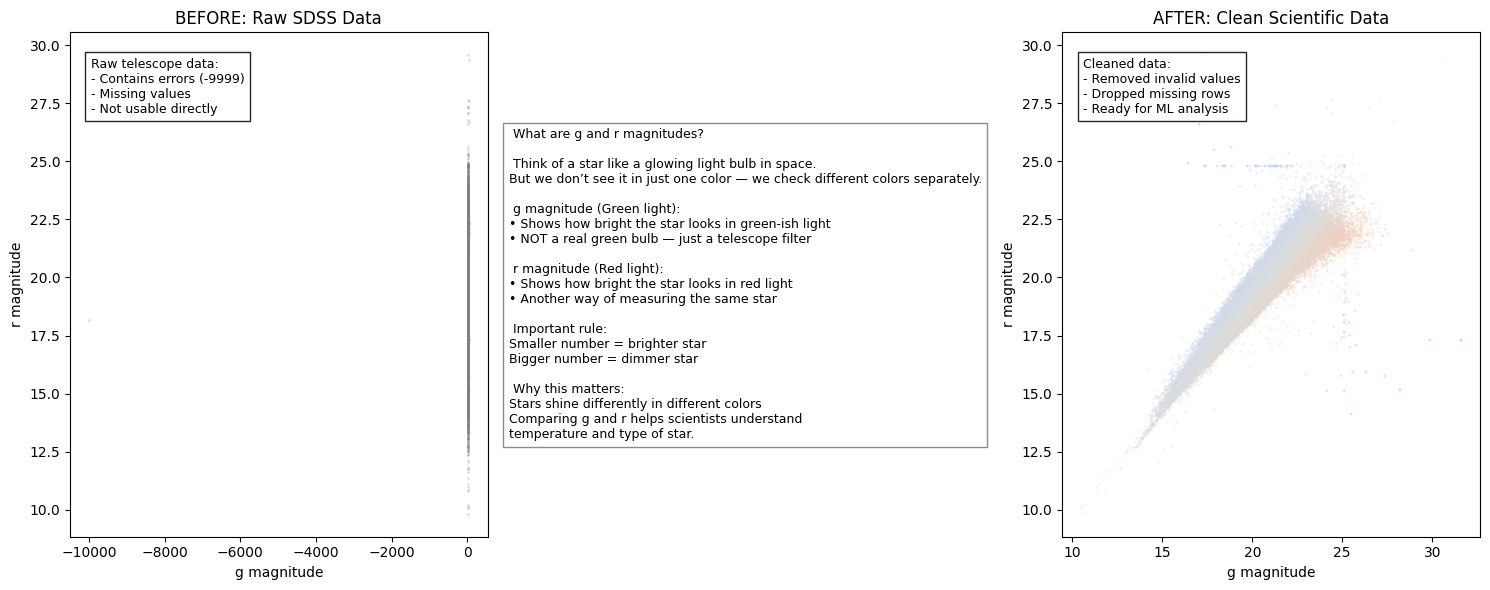

Model training completed
Model Accuracy: 0.879
Prediction: ['GALAXY']
Actual: QSO


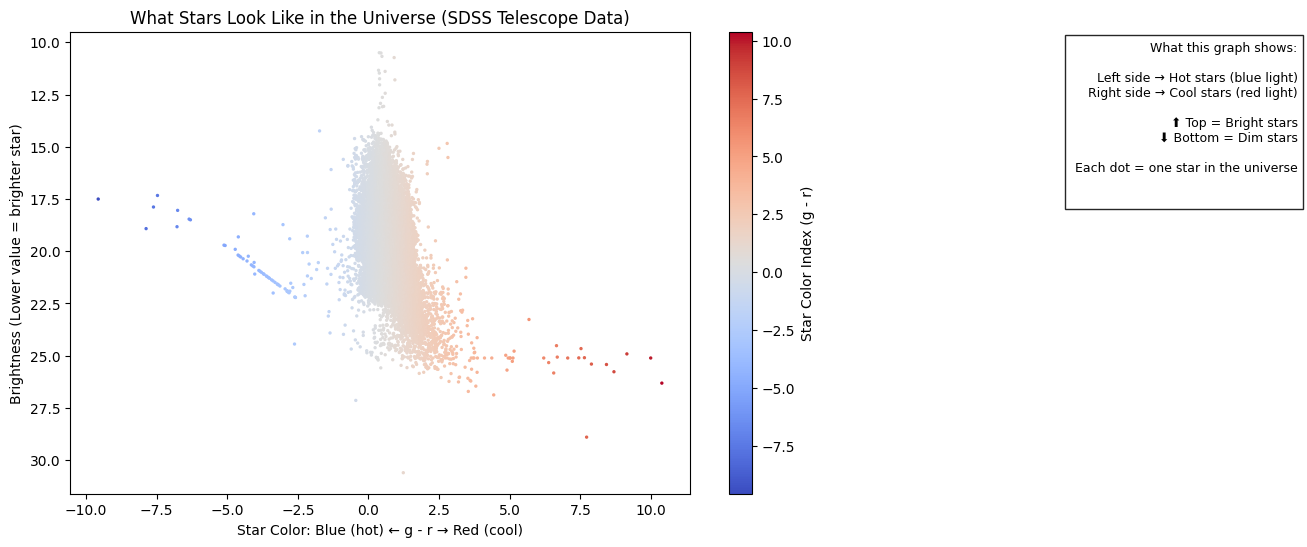

  Feature  Importance
4       z    0.261830
1       g    0.206730
0       u    0.198474
3       i    0.170956
2       r    0.162009


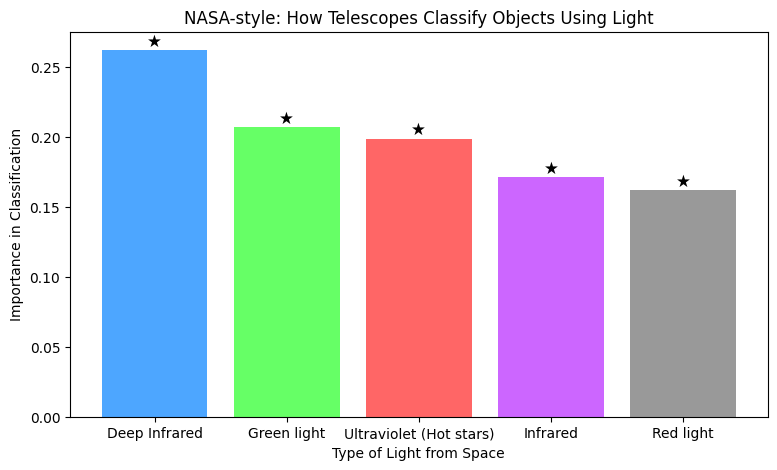

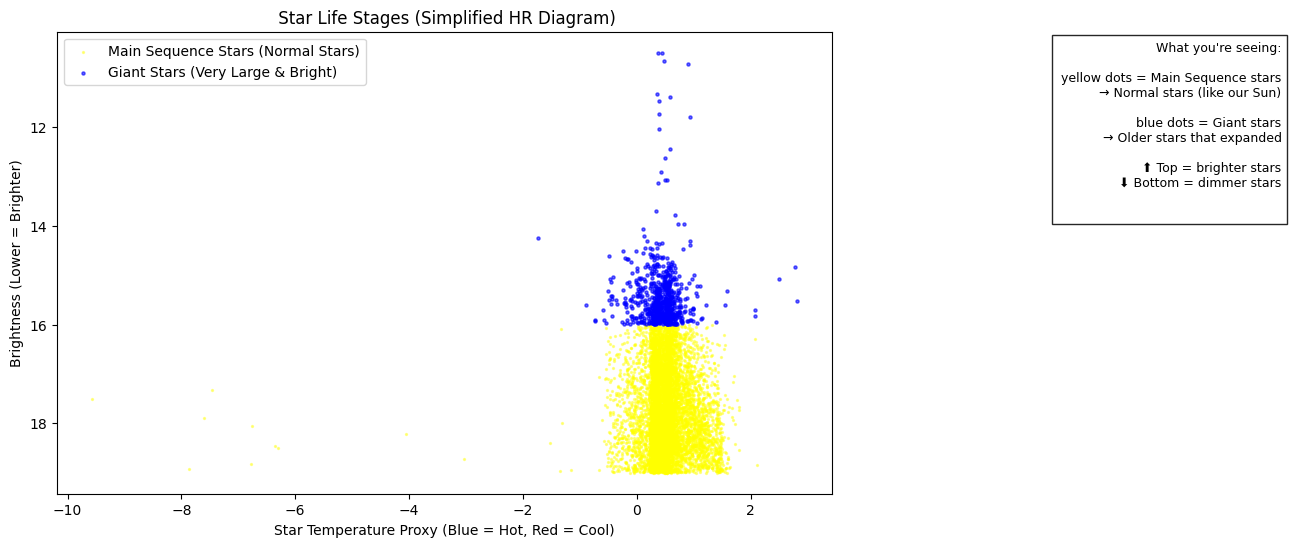

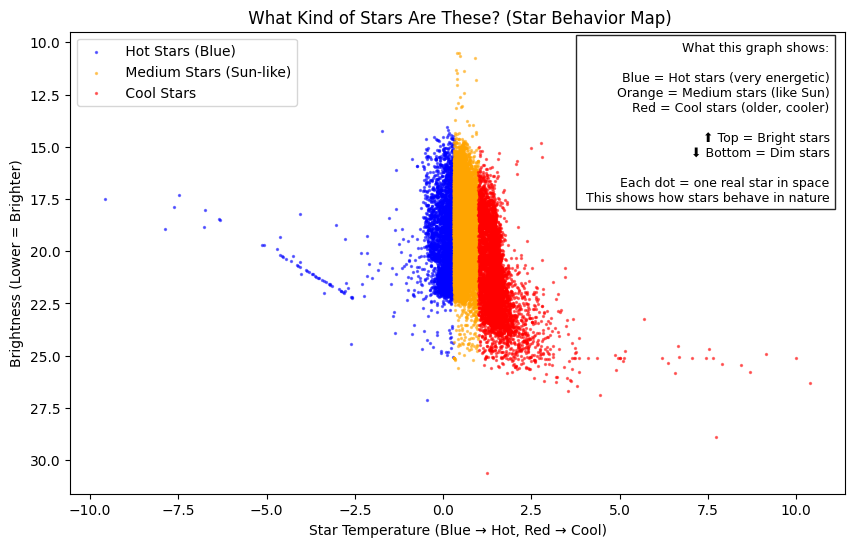

In [5]:
# =========================
# 🌟 STEP 1: Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Libraries loaded")

plt.rcParams["font.family"] = "DejaVu Sans"


# =========================
# 🌠 STEP 2: Load dataset
# =========================
df = pd.read_csv("/content/sample_data/star_classification.csv", on_bad_lines="skip")

print("Dataset loaded")
print("Shape:", df.shape)


# =========================
# 🧹 STEP 3: Clean dataset
# =========================
df_clean = df.copy()

df_clean = df_clean.replace([-9999, -9999.0], np.nan)
df_clean = df_clean.dropna(subset=["u", "g", "r", "i", "z", "class"])

print("Clean dataset shape:", df_clean.shape)


# =========================
# 🌈 STEP 4: Create color features
# =========================
df_clean["u_g"] = df_clean["u"] - df_clean["g"]
df_clean["g_r"] = df_clean["g"] - df_clean["r"]

print("Features created")


# =========================
# ⭐ STEP 5: Filter stars
# =========================
stars = df_clean[df_clean["class"] == "STAR"].copy()

print("Stars shape:", stars.shape)



# =========================
# ⚠️ STEP 7: BEFORE vs AFTER CLEANING
# =========================
fig, axes = plt.subplots(1, 2, figsize=(15,6))


# BEFORE
axes[0].scatter(df["g"], df["r"], s=1, alpha=0.2, color="gray")
axes[0].set_title("BEFORE: Raw SDSS Data")
axes[0].set_xlabel("g magnitude")
axes[0].set_ylabel("r magnitude")

axes[0].text(
    0.05, 0.95,
    "Raw telescope data:\n"
    "- Contains errors (-9999)\n"
    "- Missing values\n"
    "- Not usable directly",
    transform=axes[0].transAxes,
    va="top",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.85)
)


# AFTER
axes[1].scatter(df_clean["g"], df_clean["r"], s=1, alpha=0.2, c=df_clean["g_r"], cmap="coolwarm")
axes[1].set_title("AFTER: Clean Scientific Data")
axes[1].set_xlabel("g magnitude")
axes[1].set_ylabel("r magnitude")

axes[1].text(
    0.05, 0.95,
    "Cleaned data:\n"
    "- Removed invalid values\n"
    "- Dropped missing rows\n"
    "- Ready for ML analysis",
    transform=axes[1].transAxes,
    va="top",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.85)
)


axes[0].text(
    1.05, 0.5,
    " What are g and r magnitudes?\n\n"
    " Think of a star like a glowing light bulb in space.\n"
    "But we don’t see it in just one color — we check different colors separately.\n\n"
    " g magnitude (Green light):\n"
    "• Shows how bright the star looks in green-ish light\n"
    "• NOT a real green bulb — just a telescope filter\n\n"
    " r magnitude (Red light):\n"
    "• Shows how bright the star looks in red light\n"
    "• Another way of measuring the same star\n\n"
    " Important rule:\n"
    "Smaller number = brighter star\n"
    "Bigger number = dimmer star\n\n"
    " Why this matters:\n"
    "Stars shine differently in different colors\n"
    "Comparing g and r helps scientists understand\n"
    "temperature and type of star.",
    transform=axes[0].transAxes,
    fontsize=9,
    va="center",
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
)



plt.tight_layout()
plt.show()

#

# =========================
# 🤖 STEP 8: MACHINE LEARNING MODEL
# =========================
features = ["u", "g", "r", "i", "z"]

X = df_clean[features]
y = df_clean["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training completed")


# =========================
# 📊 STEP 9: ACCURACY
# =========================
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Model Accuracy:", acc)


# =========================
# 🔭 STEP 10: SAMPLE PREDICTION
# =========================
sample = X_test.iloc[0:1]

print("Prediction:", model.predict(sample))
print("Actual:", y_test.iloc[0])

# =========================
# 🌌 STEP 6: STAR COLOR DIAGRAM
# =========================
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    stars["g_r"],
    stars["g"],
    s=2,
    c=stars["g_r"],
    cmap="coolwarm"
)

plt.gca().invert_yaxis()

plt.colorbar(scatter, label="Star Color Index (g - r)")

plt.xlabel("Star Color: Blue (hot) ← g - r → Red (cool)")
plt.ylabel("Brightness (Lower value = brighter star)")
plt.title("What Stars Look Like in the Universe (SDSS Telescope Data)")





# 🌠 Explanation box (simple human version)
plt.text(
    1.98, 0.98,
    "What this graph shows:\n\n"
    "Left side → Hot stars (blue light)\n"
    "Right side → Cool stars (red light)\n\n"
    "⬆ Top = Bright stars\n"
    "⬇ Bottom = Dim stars\n\n"
    " Each dot = one star in the universe\n\n",
    transform=plt.gca().transAxes,
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(facecolor="white", alpha=0.85)
)
plt.show()



# =========================
# 🌌 NASA STYLE FEATURE VISUAL
# =========================

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)
feature_name_map = {
    "u": "Ultraviolet (Hot stars)",
    "g": "Green light",
    "r": "Red light",
    "i": "Infrared",
    "z": "Deep Infrared"
}

feature_importance["Pretty Feature"] = feature_importance["Feature"].map(feature_name_map)

plt.figure(figsize=(9,5))

bars = plt.bar(
    feature_importance["Pretty Feature"],
    feature_importance["Importance"],
    color=["#4da6ff", "#66ff66", "#ff6666", "#cc66ff", "#999999"]
)

plt.title("NASA-style: How Telescopes Classify Objects Using Light")
plt.xlabel("Type of Light from Space")
plt.ylabel("Importance in Classification")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        "★",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.show()


# =========================
# 🌌 STAR LIFE STAGES (HR DIAGRAM STYLE)
# Main Sequence vs Giants (approximation)
# =========================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# Temperature proxy (color index)
temp = stars["g_r"]

# Brightness
brightness = stars["g"]

# -------------------------
# SIMPLE CLASSIFICATION RULE (approx)
# -------------------------
# Main Sequence: normal stars
main_seq = stars[brightness < 19]

# Giants: very bright stars (lower magnitude = brighter)
giants = stars[brightness <= 16]

# remove overlap cleanly
main_seq = main_seq.drop(giants.index, errors="ignore")


# -------------------------
# PLOT MAIN SEQUENCE
# -------------------------
plt.scatter(
    main_seq["g_r"],
    main_seq["g"],
    s=2,
    c="yellow",
    alpha=0.4,
    label="Main Sequence Stars (Normal Stars)"
)

# -------------------------
# PLOT GIANTS
# -------------------------
plt.scatter(
    giants["g_r"],
    giants["g"],
    s=5,
    c="blue",
    alpha=0.6,
    label="Giant Stars (Very Large & Bright)"
)

plt.gca().invert_yaxis()

plt.title(" Star Life Stages (Simplified HR Diagram)")
plt.xlabel("Star Temperature Proxy (Blue = Hot, Red = Cool)")
plt.ylabel("Brightness (Lower = Brighter)")
plt.legend()


# -------------------------
# EXPLANATION BOX
# -------------------------
plt.text(
    1.58, 0.98,
    " What you're seeing:\n\n"
    " yellow dots = Main Sequence stars\n"
    "   → Normal stars (like our Sun)\n\n"
    " blue dots = Giant stars\n"
    "   → Older stars that expanded\n\n"
    "⬆ Top = brighter stars\n"
    "⬇ Bottom = dimmer stars\n\n",
    transform=plt.gca().transAxes,
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(facecolor="white", alpha=0.85)
)



plt.show()


# 🌌 STAR BEHAVIOR MAP
# Type of star vs brightness
# =========================


# Temperature proxy
color_index = stars["g_r"]
brightness = stars["g"]

# -------------------------
# CLASSIFY STAR TYPE
# -------------------------
hot = stars[color_index < 0.3]
medium = stars[(color_index >= 0.3) & (color_index < 1.0)]
cool = stars[color_index >= 1.0]

plt.figure(figsize=(10,6))

# -------------------------
# HOT STARS
# -------------------------
plt.scatter(
    hot["g_r"], hot["g"],
    s=2, c="blue", alpha=0.5,
    label=" Hot Stars (Blue)"
)

# -------------------------
# MEDIUM STARS
# -------------------------
plt.scatter(
    medium["g_r"], medium["g"],
    s=2, c="orange", alpha=0.5,
    label=" Medium Stars (Sun-like)"
)

# -------------------------
# COOL STARS
# -------------------------
plt.scatter(
    cool["g_r"], cool["g"],
    s=2, c="red", alpha=0.5,
    label=" Cool Stars"
)

# Invert brightness (astronomy rule)
plt.gca().invert_yaxis()

plt.title(" What Kind of Stars Are These? (Star Behavior Map)")
plt.xlabel("Star Temperature (Blue → Hot, Red → Cool)")
plt.ylabel("Brightness (Lower = Brighter)")
plt.legend()


# -------------------------
# EXPLANATION BOX
# -------------------------
plt.text(
    0.98, 0.98,
    " What this graph shows:\n\n"
    " Blue = Hot stars (very energetic)\n"
    " Orange = Medium stars (like Sun)\n"
    " Red = Cool stars (older, cooler)\n\n"
    "⬆ Top = Bright stars\n"
    "⬇ Bottom = Dim stars\n\n"
    " Each dot = one real star in space\n"
    " This shows how stars behave in nature",
    transform=plt.gca().transAxes,
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(facecolor="white", alpha=0.85)
)

plt.show()